# Ray Tracing in 15 minutes

Ray Tracing is one of the most interesting Computer Graphics algorithms out there, used in [tons of games](https://www.corsair.com/us/en/explorer/gamer/gaming-pcs/what-is-ray-tracing-in-games/) as a default now. It was, for a long time, considered to be too slow compared to traditional methods like [rasterization](https://blogs.nvidia.com/blog/whats-difference-between-ray-tracing-rasterization/) and [scanline rendering](https://hackaday.io/project/11815-quicksilver-neo-open-source-gpu/log/38395-chasing-the-scanline). But with the advent of Graphics Processing Units (GPUs) and tensor programming, it became accessible to millions of developers.


In this notebook, I'm going to try and explain how you can go from zero to a basic understanding of what's going on under the hood. This is only meant to be an *introduction* and does not cover next steps like Reflections, Shadows etc. (yet), but it does cover integral topics like Phong Shading. It is also mostly light on math, but will play on giving you an intuition. The diag


This is implemented with PyTorch, and can be similarly implemented in NumPy or other simpler numerical computing platforms with the same principles in place.

<img src = 'https://drive.google.com/uc?id=1s6qMF0k755WGVp8UuFnzta-ctjBqqssB'>

(created by [Suvaditya Mukherjee](https://suvadityamuk.com))

# Step 1 - Initialize the current world with light, camera, and object

## Imports and PyTorch setup

We quickly set up the accelerator of choice. This notebook should run fine on a NVIDIA T4 provided for free on Colab.

In [15]:
import math
import torch
from torch import nn
import matplotlib.pyplot as plt
from PIL import Image

def get_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
    print(f"Using device: {device}")
    return device

device = get_device()

Using device: cuda


## Scene setup

We set up the following things

- **Frame Dimensions**: This sets up the image plane's dimensions, this is the expected size of the final image we get
- **Field of View**: This determines the size of the frustum that defines how much of the periphery our camera sees
- **Camera location**: A 3D point in space that defines where the camera is placed. This is the center of the camera.
- **Light direction**: We assume a directional point light for simplicity, and to do so, we define in what direction the light is being applied
- **Light color**: We can choose the color of our light. They are determined in the `R / 255.0`, `G / 255.0`, `B / 255.0` space (which makes `[1.0, 1.0, 1.0]` a white light)
- **Specular exponent**: In short, a exponent value that determines how bright the reflection would be. We will talk about this a bit more down the line.
- **Ambient, Diffuse, Specular components**: A value that determines how each component of Phong shading will mix our colors. This will also be covered down the line.

(figure not to scale)

<img src = 'https://drive.google.com/uc?id=1TBmXDVMdS39UQ3XfiuRaA3WT_Ln9SSit'>

In [16]:
frame_height = 512
frame_width = 512
fov = math.radians(60)

# Try playing around with this by moving it along -z axis!
camera_loc = torch.tensor([0.0, 0.0, -1.0], device=device)

sphere_loc = torch.tensor([0.0, 0.0, -4.0], device=device)
sphere_color = torch.tensor([0.0, 1.0, 0.0], device=device)
sphere_radius = 1.0

light_dir = torch.tensor([1.0, 1.0, -1.0], device=device)
light_dir = light_dir / torch.norm(light_dir)
light_color = torch.tensor([1.0, 1.0, 1.0], device=device)

specular_exponent = 5.0

ambient_component = 0.1
diffuse_component = 0.3
specular_component = 0.6

# Step 2 - Generate one ray per pixel

Here, we're gonna create a quick way to reference/index our camera plane, but we do so by creating a `torch.meshgrid` that yields lists of numbers that we can use to index specific pixel points and/or full rows or columns or their combinations easily.

<img src = 'https://drive.google.com/uc?id=1ppvmzRvJkKqWc_gCR2l1actiB9eOFNtO'>

In [17]:
xs, ys = torch.meshgrid(
    torch.arange(frame_width),
    torch.arange(frame_height),
    indexing="xy",
)
xs = xs.to(device)
ys = ys.to(device)

# Step 3 - Map pixel coordinates to camera plane coordinates

In our "world", any given point can be expressed as a combination of 3 floating-point numbers, the X, Y, Z co-ordinates. These are also known as "world coordinates". In our scene, objects are defined in world coordinates, which are general 3D coordinates and are not normalized by frame dimensions. To render an image, we conceptually transform points from world space into camera space using the camera's pose.

But, to operate on the camera plane and create viewing rays, we need to make use of coordinates which make sense for the camera screen plane. Hence, we need to define a transformation from the pixel coordinate space to the camera space. Co-ordinates used on a camera screen are known as "normalized screen coordinates".

For our normalized screen, the coordinates will range between $(-1, 1)$, where $(0, 0)$ is the exact center of our camera plane. We assume that the camera axes are in the same orientation as of our world axes, which eliminates the rotation operation for us. We can assume that each pixel is of unit size, which would mean to get the center of a pixel, we must add 0.5 to each coordinate.

To sum up, our operations below will first take the pixel coordinates to get through the following transformation

- `(X, Y)` -> Range of (frame_width, frame_height) which acts as the starting point

- `(X + 0.5, Y + 0.5)` -> Maps to center of pixel instead of top-left corner

- `(tx = (X + 0.5) / frame_width, ty = (Y + 0.5) / frame_height)` -> Normalizes coordinate value to (0, 1)

- `(2 * tx, 2 * ty)` -> Maps values to a range of (0, 2)

- `(2 * tx - 1, 2 * ty - 1)` -> Maps values to a range of (-1, 1)

Now, our coordinates are in the normalized screen plane (or put simply, defined with respect to our camera screen origin instead of the world origin) and are ready to be used for operation in the device screen space itself.

<img src = 'https://drive.google.com/uc?id=1LE6ldLcD2RYCxVIM8oB1imTAjFgS_7qJ'>

In [18]:
x_screen_normalized = 2 * ((xs + 0.5) / frame_width) - 1
y_screen_normalized = 2 * ((ys + 0.5) / frame_height) - 1

# Step 4 - Set up near plane

Now that we have normalized screen coordinates, we can map them to a plane that reflects what our image screen should look like. Any viewing ray passing through a corresponding point on this plane will be represented as a pixel on our image.

To do so, we make use of the field-of-view angle and use it to determine how much we must scale our normalized coordinates in order to get a direct representation of the camera's near/image plane directly.

We also scale our X-axis by the aspect ratio to make sure that it remains proportional to the Y-axis according to our frame dimensions.

<img src = 'https://drive.google.com/uc?id=1TncfRa5ejdX2zbdtUqKw-6I1HO5ztbez'>

In [19]:
x_camera_plane = x_screen_normalized * math.tan(fov / 2) * (frame_width / frame_height)
y_camera_plane = y_screen_normalized * math.tan(fov / 2)

# Step 5 - Point ray from camera to image plane

A ray is defined by the equation $r = o + (t * d)$, where o is the origin of the ray, t is a certain distance multiple, and d is a direction vector that is generally of unit magnitude. Using this equation, we can define a ray that starts at origin o, and then traverses t units in d direction.

Now that we have the `camera_loc` variable as our origin and we also have a position on our camera plane (that is defined in camera coordinates, i.e. with respect to the camera location and not the world location), we can define the unit direction in which each ray will go.

Once defined, we will also normalize this to get an unit vector that points in the desired direction.

We use -1 in the Z-axis because we say that the near plane of the camera is located at -1 distance from the camera, i.e. 1 unit in the -Z direction. We assume that our camera is looking along the negative Z-direction.

<img src = 'https://drive.google.com/uc?id=1eABwrjKBR7ldnfXZJuxm3zmZfCC_v0__'>

In [20]:
ray_dirs = torch.stack([
    x_camera_plane,
    y_camera_plane,
    -torch.ones_like(x_camera_plane)
], dim=-1)

ray_dirs = ray_dirs / torch.norm(ray_dirs, dim=-1, keepdim=True)

# Step 6 - Ray - Sphere intersection

The process of ray tracing is done to launch rays from the camera plane into the world, and trace them backwards to see where they have come from. As we do that, we shade the pixels in the colors of the objects we see as it would appear from that angle. Hence, we literally "trace" the paths of rays that would lie on the image plane.

In our example, we will only look at a single object type, that is a Sphere. We do so because it is fairly simple to define, and also easy to check against.

To check if a ray intersects a sphere or not, we can simply see the 2 equations we have at hand. A ray is defined as $r = o + (t * d)$ whereas a sphere is defined as $||x - c||^2 = r^2$ where x stands for the point we are testing, c is the sphere center, and r is the sphere radius.

In our case, since we want to check if the ray is intersecting the sphere or not, we simply substitute the ray equation as x for the sphere equation. This gives us a final quadratic equation, where we solve for t to get the number of units we must travel in the direction defined by d to reach an intersection point.

$(d⋅d)t^2+2(d⋅m)t+(m⋅m−R^2)=0$

where $m = o - c$

<img src = 'https://drive.google.com/uc?id=1EDHWuugxvuUuzbUmsuS2-6M9KOm7t5_-'>

In [21]:
origin_sphere_center_vec = camera_loc - sphere_loc

b = 2.0 * torch.sum(ray_dirs * origin_sphere_center_vec, dim=-1)
c = torch.sum(origin_sphere_center_vec * origin_sphere_center_vec, dim=-1) - sphere_radius ** 2

discriminant = b ** 2 - 4.0 * c

hit_mask = discriminant >= 0.0

# Step 7 - Get valid t (of formula o + td) from intersection discriminant

We must now check the discriminant of this quadratic equation to say that if:

- discriminant is imaginary, we can say that the ray does not meet the sphere at all
- discriminant is real and roots are 0, then we can say that there was exactly one intersection point which is possible if the ray just grazes tangentially to the sphere and that this point is at the ray origin itself
- discriminant is real and roots are positive, we can say that they occur in front of the camera and should be visible
- discriminant is real and roots are negative, we can say that the ray intersection happens, but it occurs behind the camera's current location

All in all, our process will have us do the following:

- Take each ray
- Check if the ray intersects with the sphere
- If it does, assign the color of the sphere at the intersection point to that ray
- If it does not, assign the background color which denotes that the ray shot into infinity.

When there are multiple objects, we must check each object to see whether the ray hits them or not. There are multiple optimization strategies which exist to reduce the number of objects we must check for a given ray instead of checking every object all the time (such as Bounding Volume Hierarchies), but those aren't applied here since our scene is extremely simple and has only one single sphere.

In [22]:
sqrt_discriminant = torch.sqrt(torch.clamp(discriminant, min=0.0))

t0 = (-b - sqrt_discriminant) / 2.0
t1 = (-b + sqrt_discriminant) / 2.0

# Step 8 - Apply t to ray and get intersection point

We use the roots we get to understand which rays did hit the sphere and which did not. Based on that, we recreate the actual rays using our equation by plugging in the value of t we got in the last step. This gives us an equation of a ray that stretches from the origin of the camera all the way to the exact intersection point of that ray with the sphere.

Based on this, we can now also define vectors that give us the normal (90°) direction of the spherical surface at a given point (something we're going to need soon enough). To do so, we take a vector from the sphere center to the intersection point. Lastly, we normalize it to make sure we only represent a direction with unit magnitude.

<img src = 'https://drive.google.com/uc?id=1tvUV8BEq1-nKWo2as7mVKxjM2DMS5hyp'>

In [23]:
t = torch.where(t0 > 0, t0, t1)
hit_mask = hit_mask & (t > 0)

intersection_points = camera_loc + ray_dirs * t[..., None]

surface_normal_vecs = (intersection_points - sphere_loc)
surface_normal_vecs = surface_normal_vecs / torch.norm(surface_normal_vecs, dim=-1, keepdim=True)

# Step 9 - Apply Phong Shading

Phong Shading, named after it's creator Bui Tuong Phong, describes how we can determine the correct colors for a ray. It is one of many different techniques, but is among the simplest and needs the lowest amount of computations per pixel.

Consider the word "shading" here as "applying a function". Keeping that in mind, we can consider Phong Shading as a function that determines color for a given ray.

It defines 3 color components, which are

- Diffuse/Lambertian Component: This is the natural color of the object that is determined by how much light is reflected off of the surface of an object. This is calculated by a dot product between the surface normal and the light direction vector.

- Ambient Component: This is the environment's light/color that appears on the object and has no connection to the actual light being used. These are directly used without any vector calculations.

- Specular Component: These are bright highlights that appear on an object that makes them appear shiny. They appear at specific spots where the reflected rays coming from the light appear directly in the same direction as that of the viewer, which are then amplified/raised by a power to determine how "shiny" a material/object is.

<img src = 'https://drive.google.com/uc?id=1pL3E-2Cs3sO8ailnrDzbGnvYgblsp5ak'>


In [24]:
diffuse = torch.clamp(torch.sum(surface_normal_vecs * (-light_dir), dim=-1), min=0.0)

reflected = 2.0 * torch.sum(surface_normal_vecs * (-light_dir), dim=-1)[..., None] * surface_normal_vecs - (-light_dir)
specular = torch.clamp(torch.sum(reflected * -(ray_dirs), dim=-1), min=0.0) ** specular_exponent


Given each shade, we then mix them together in a desired proportion (where all the proportions put together sum up to 1). The final color determined by this process is what we assign to the ray.


In [25]:
shading = ambient_component + diffuse * diffuse_component

# Step 10 - Render Image and Save

There we go! We have our shading ops ready, and now we're going to apply it to get the final image.

In [26]:
# If you want to render a black background, use this

# image = torch.zeros((frame_height, frame_width, 3), device=device)

# If you want to render a background with a specific color with the
# same R=G=B values, use this

# image = torch.full((frame_height, frame_width, 3), 1.0, device=device)

# If you want to mix and match R,G,B values to get a specific background
# color, use this (where R/255.0, G/255.0, B/255.0)
bg_r_color = 0.0
bg_g_color = 0.0
bg_b_color = 0.0

bg_r = torch.full((frame_height, frame_width), bg_r_color, device=device)
bg_g = torch.full((frame_height, frame_width), bg_g_color, device=device)
bg_b = torch.full((frame_height, frame_width), bg_b_color, device=device)

image = torch.stack([bg_r, bg_g, bg_b], dim=-1)

image[hit_mask] = sphere_color * shading[hit_mask][..., None]
image[hit_mask] += light_color * specular[hit_mask][..., None]

image = torch.clamp(image, min=0.0, max=1.0)
image = (image * 255).byte().cpu().numpy()

final_image = Image.fromarray(image)
final_image.save("raytrace_sphere.png")
print("Saved image - raytrace_sphere.png")

Saved image - raytrace_sphere.png


# Step 11 - Display Image!

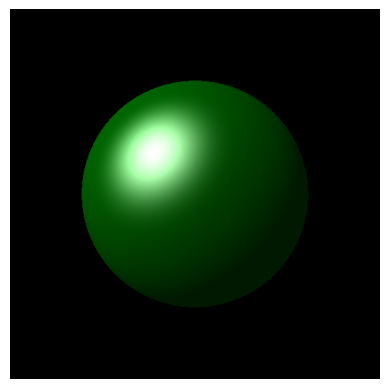

In [27]:
plt.imshow(image)
plt.axis('off')
plt.show()

# Conclusion

In this example, we looked at how we can define a sample environment and then go from a basic setup all the way to generating an image of a sphere with Ray-Tracing and Phong shading.

To go further from here, I highly recommend trying to implement reflections (to do so, you must track the rays reflected off of objects), checking multiple objects (run the intersection check once every time on each object) and shadows (track vectors going from objects towards light sources and check if they intersect any objects)

Future resources:

- [Ray Tracing in one weekend](https://raytracing.github.io/books/RayTracingInOneWeekend.html) - A much more grounded and neat resource (inspired me for the name!)
- [What is Ray Tracing by NVIDIA](https://developer.nvidia.com/discover/ray-tracing) - Their hardware enabled it, so they know best!

Thank you for following along!

If you want to see more, feel free to check out [my website](https://www.suvadityamuk.com), or follow me on [X/Twitter](https://x.com/halcyonrayes), [LinkedIn](https://linkedin.com/in/suvadityamukherjee), and [GitHub](https://github.com/suvadityamuk).

Highly appreciate it if you ⭐ the repository!